# Apartment Rental Price Prediction – Zurich Area

**Course:** AI Applications  
**Assignment:** Machine Learning Web Application  
**Date:** March 2026

---

## Objective

This notebook documents the full data-science workflow for predicting **monthly apartment rental prices (CHF)** in the Greater Zurich area. The project follows an iterative modelling approach:

1. **Iteration 1 – Baseline:** Build a performance baseline using basic apartment features (size, rooms).
2. **Iteration 2 – Extended:** Improve accuracy by adding three engineered features: distance to Zurich centre, furnished flag, and parking flag.

The best model is deployed in a Streamlit web application (`streamlit_app.py`).

### Table of Contents
1. [Setup and Data Loading](#1-setup-and-data-loading)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
3. [Missing Value Inspection](#3-missing-value-inspection)
4. [Outlier Inspection](#4-outlier-inspection)
5. [Feature Engineering](#5-feature-engineering)
6. [Iteration 1 – Baseline Modelling](#6-iteration-1--baseline-modelling)
7. [Iteration 2 – Extended Features](#7-iteration-2--extended-features)
8. [Model Comparison and Selection](#8-model-comparison-and-selection)
9. [Conclusion](#9-conclusion)

---
## 1. Setup and Data Loading

In [1]:
# Set working directory to project root so relative imports work
import os
import sys

# Move from notebooks/ up to the project root
project_root = os.path.abspath('..')
os.chdir(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f'Working directory: {os.getcwd()}')

Working directory: /workspaces/Exercise-Apartment-Price-Prediction-Application


In [2]:
# Core imports
import math
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42

print('Imports successful.')

Imports successful.


In [3]:
# Generate raw data if it does not yet exist
from pathlib import Path

if not Path('data/apartments_zurich_raw.csv').exists():
    print('Raw data missing – generating now…')
    import generate_sample_data  # runs the generation on import
    generate_sample_data.generate_dataset(n=700).to_csv(
        'data/apartments_zurich_raw.csv', index=False
    )
    print('Raw data created.')

# Load raw data
raw_df = pd.read_csv('data/apartments_zurich_raw.csv')
print(f'Raw dataset: {raw_df.shape[0]} rows × {raw_df.shape[1]} columns')
display(raw_df.head(8))

Raw dataset: 700 rows × 11 columns


,title,description,price,number_of_rooms,apartment_size_sqm,address,zip_code,city,latitude,longitude,publisher
0,Helle 3.5-Zimmer-Mietwohnung – Uster,Gepflegte Wohnung in sehr gutem Zustand. Moder...,1970.0,3.5,66.5,Weinbergstrasse 7,8610,Uster,47.348080,8.720802,Helvetia Immobilien
1,Möblierte 2.5-Zimmer-Wohnung in Zürich,Die Wohnung ist vollständig möbliert und direk...,2430.0,2.5,73.9,Forchstrasse 109,8064,Zürich,47.389582,8.495870,Homegate
2,Moderne 1.5-Zimmer-Apartment in Uster,Gepflegte Wohnung in sehr gutem Zustand. Ruhig...,1260.0,1.5,48.8,Aargauerstrasse 140,8610,Uster,47.350144,8.719929,Procimmo
3,Moderne 3.5-Zimmer-Wohnung in Zürich,Gepflegte Wohnung in sehr gutem Zustand. Südau...,3760.0,3.5,104.5,Heinrichstrasse 72,8004,Zürich,47.372580,8.524702,ImmoScout24
4,Helle 1-Zimmer-Mietwohnung – Dietikon,Gepflegte Wohnung in sehr gutem Zustand. Ideal...,870.0,1.0,35.5,Limmatstrasse 89,8953,Dietikon,47.402971,8.402216,ImmoScout24
5,Moderne 3.5-Zimmer-Mietwohnung in Dübendorf,Gepflegte Wohnung in sehr gutem Zustand. Frisc...,2750.0,3.5,96.3,Bucheggstrasse 93,8603,Dübendorf,47.391705,8.632969,Livit AG
6,Schöne 2.5-Zimmer-Wohnung in Küsnacht,Gepflegte Wohnung in sehr gutem Zustand. Moder...,2610.0,2.5,71.5,Forchstrasse 60,8700,Küsnacht,47.310600,8.579922,Privat
7,Geräumige 3-Zimmer-Mietwohnung in Zürich,Gepflegte Wohnung in sehr gutem Zustand. Moder...,3550.0,3.0,76.2,Rosengartenstrasse 19,8001,Zürich,47.375455,8.537517,Livit AG


---
## 2. Exploratory Data Analysis

In [4]:
print('=== DataFrame Info ===')
raw_df.info()

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               700 non-null    object 
 1   description         700 non-null    object 
 2   price               700 non-null    float64
 3   number_of_rooms     682 non-null    float64
 4   apartment_size_sqm  687 non-null    float64
 5   address             700 non-null    object 
 6   zip_code            700 non-null    int64  
 7   city                700 non-null    object 
 8   latitude            676 non-null    float64
 9   longitude           683 non-null    float64
 10  publisher           700 non-null    object 
dtypes: float64(5), int64(1), object(5)
memory usage: 60.3+ KB


In [5]:
print('=== Descriptive Statistics ===')
display(raw_df[['price', 'number_of_rooms', 'apartment_size_sqm']].describe().round(1))

=== Descriptive Statistics ===


,price,number_of_rooms,apartment_size_sqm
count,700.0,682.0,687.0
mean,2616.5,3.0,81.2
std,990.2,1.1,30.2
min,520.0,1.0,12.3
25%,2020.0,2.5,64.3
50%,2550.0,3.0,81.4
75%,3190.0,3.5,99.2
max,6190.0,6.0,183.0


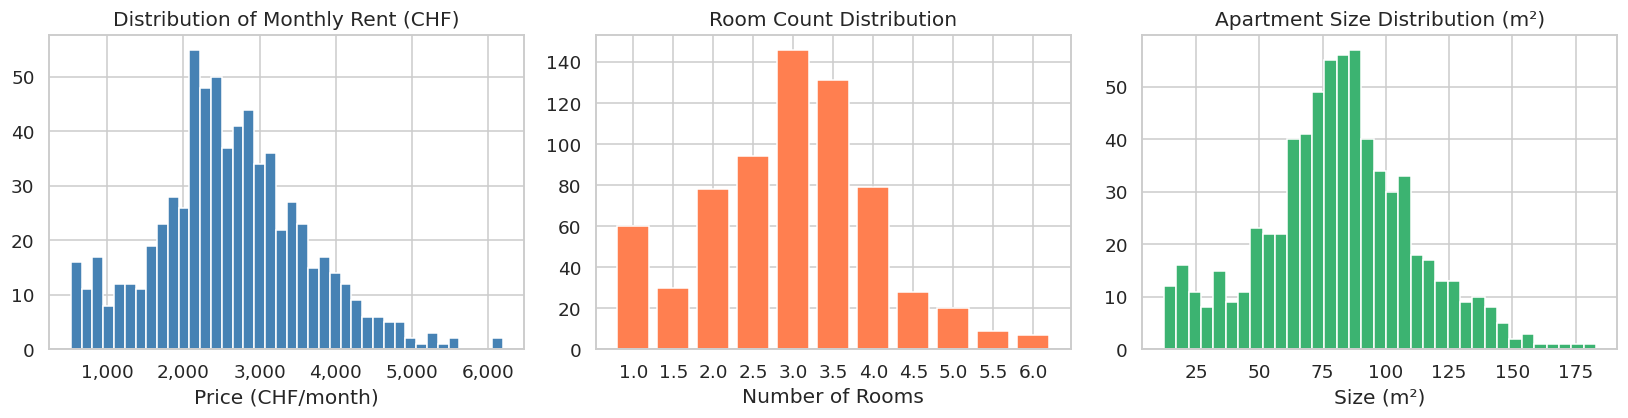

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(raw_df['price'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Monthly Rent (CHF)')
axes[0].set_xlabel('Price (CHF/month)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

room_counts = raw_df['number_of_rooms'].dropna().value_counts().sort_index()
axes[1].bar(room_counts.index.astype(str), room_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Room Count Distribution')
axes[1].set_xlabel('Number of Rooms')

axes[2].hist(raw_df['apartment_size_sqm'].dropna(), bins=35, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Apartment Size Distribution (m²)')
axes[2].set_xlabel('Size (m²)')

fig.tight_layout()
plt.show()

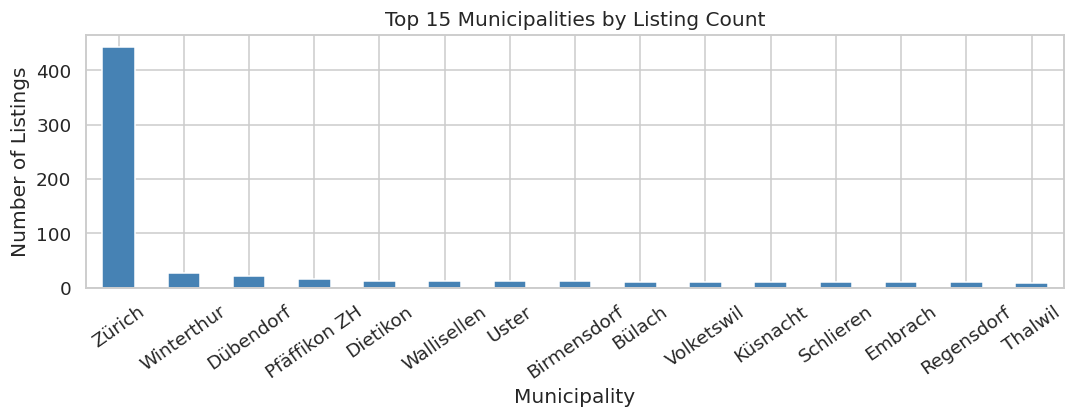

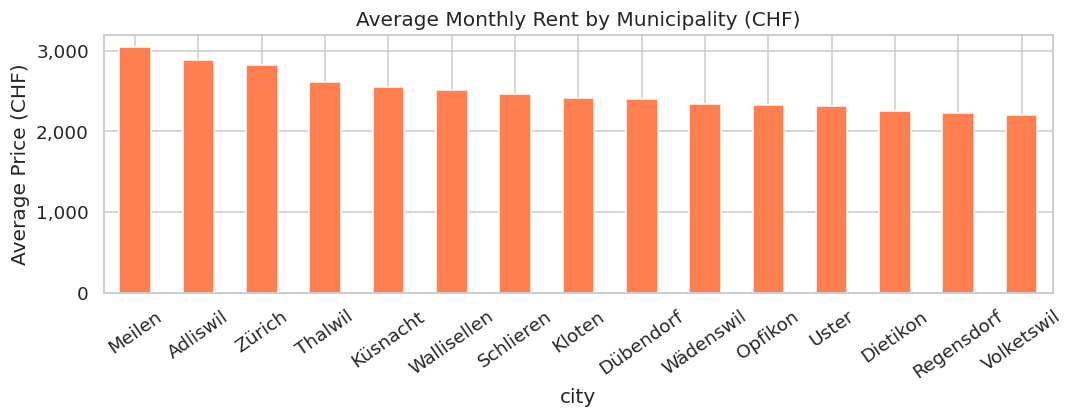

In [7]:
# Top cities by listing count
city_counts = raw_df['city'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 4))
city_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Municipalities by Listing Count')
ax.set_xlabel('Municipality')
ax.set_ylabel('Number of Listings')
ax.tick_params(axis='x', rotation=35)
fig.tight_layout()
plt.show()

# Average price per city (top 15)
avg_price = raw_df.groupby('city')['price'].mean().sort_values(ascending=False).head(15)
fig2, ax2 = plt.subplots(figsize=(10, 4))
avg_price.plot(kind='bar', ax=ax2, color='coral', edgecolor='white')
ax2.set_title('Average Monthly Rent by Municipality (CHF)')
ax2.set_ylabel('Average Price (CHF)')
ax2.tick_params(axis='x', rotation=35)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig2.tight_layout()
plt.show()

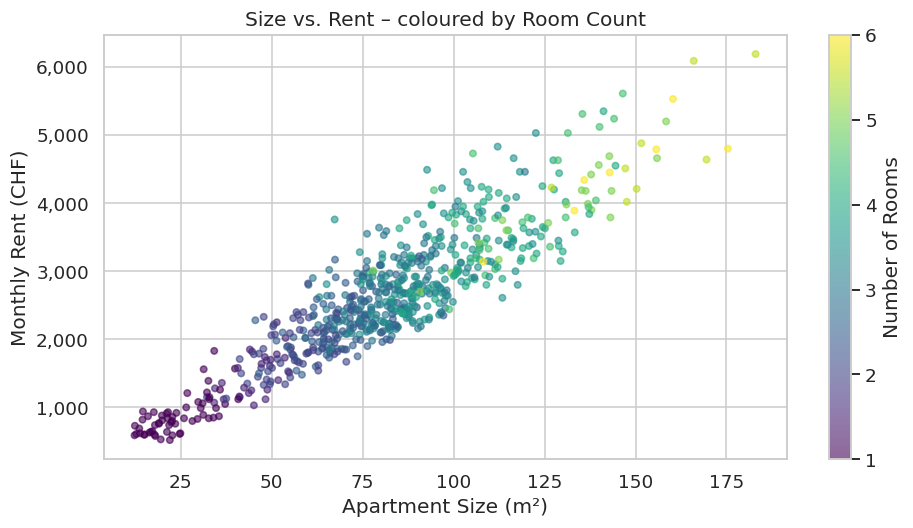

In [8]:
# Scatter: size vs price, coloured by room count
plot_df = raw_df[['apartment_size_sqm', 'price', 'number_of_rooms']].dropna()
fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    plot_df['apartment_size_sqm'], plot_df['price'],
    c=plot_df['number_of_rooms'], cmap='viridis', alpha=0.6, s=18
)
plt.colorbar(scatter, ax=ax, label='Number of Rooms')
ax.set_xlabel('Apartment Size (m²)')
ax.set_ylabel('Monthly Rent (CHF)')
ax.set_title('Size vs. Rent – coloured by Room Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig.tight_layout()
plt.show()

---
## 3. Missing Value Inspection

In [9]:
missing = raw_df.isnull().sum().rename('missing').to_frame()
missing['pct'] = (missing['missing'] / len(raw_df) * 100).round(2)
display(missing[missing['missing'] > 0].sort_values('missing', ascending=False))

,missing,pct
latitude,24,3.43
number_of_rooms,18,2.57
longitude,17,2.43
apartment_size_sqm,13,1.86


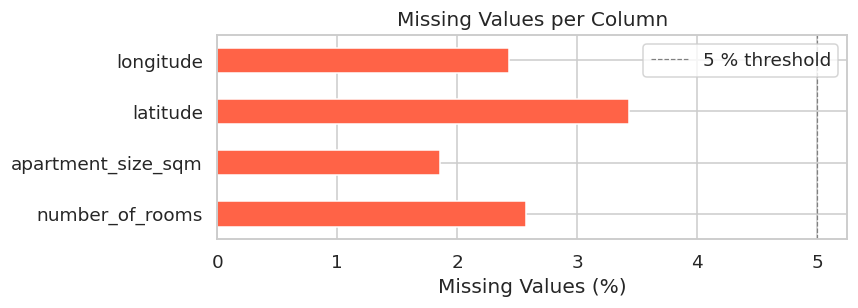


Strategy: latitude/longitude will be imputed with column medians.
Rows with missing price, size, or rooms will be dropped (filter_invalid_rows).


In [10]:
fig, ax = plt.subplots(figsize=(8, 3))
missing_pct = raw_df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0]
missing_pct.plot(kind='barh', ax=ax, color='tomato', edgecolor='white')
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Values per Column')
ax.axvline(5, color='grey', linestyle='--', linewidth=0.8, label='5 % threshold')
ax.legend()
fig.tight_layout()
plt.show()

print('\nStrategy: latitude/longitude will be imputed with column medians.')
print('Rows with missing price, size, or rooms will be dropped (filter_invalid_rows).')

---
## 4. Outlier Inspection

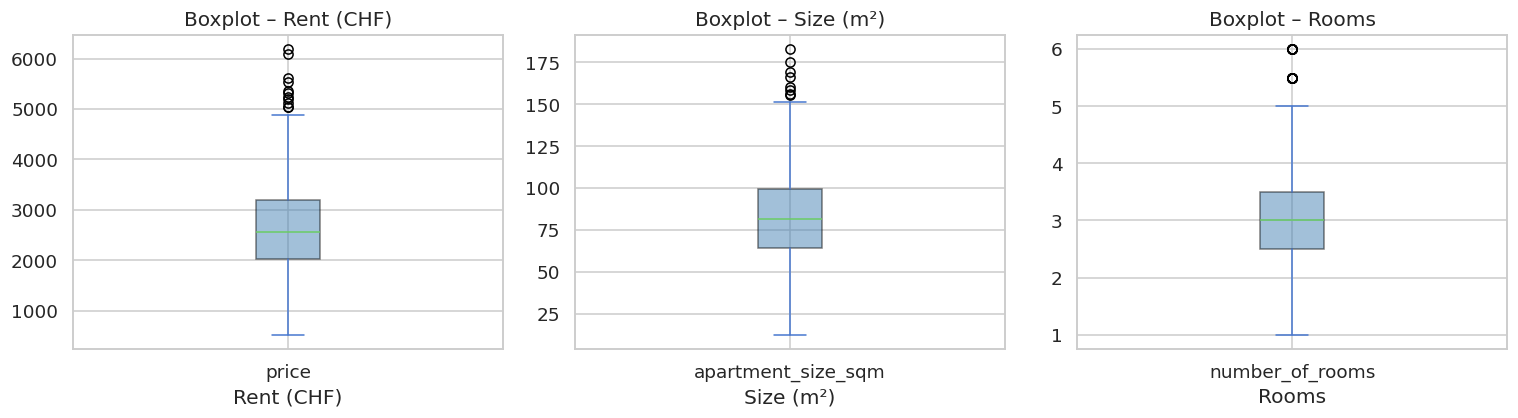


Price IQR bounds (×2.0): lower = -320, upper = 5530 CHF
Rows outside bounds: 3
Likely WG/shared-room listings (price<1000 CHF & size<30 m²): 39


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label in zip(
    axes,
    ['price', 'apartment_size_sqm', 'number_of_rooms'],
    ['Rent (CHF)', 'Size (m²)', 'Rooms']
):
    raw_df[col].dropna().plot(kind='box', ax=ax, vert=True, patch_artist=True,
                               boxprops=dict(facecolor='steelblue', alpha=0.5))
    ax.set_title(f'Boxplot – {label}')
    ax.set_xlabel(label)

fig.tight_layout()
plt.show()

# IQR stats for price
q1, q3 = raw_df['price'].quantile([0.25, 0.75])
iqr = q3 - q1
print(f'\nPrice IQR bounds (×2.0): lower = {q1 - 2*iqr:.0f}, upper = {q3 + 2*iqr:.0f} CHF')
print(f'Rows outside bounds: {((raw_df["price"] < q1-2*iqr) | (raw_df["price"] > q3+2*iqr)).sum()}')

# WG listings (low price, small size)
wg_approx = raw_df[(raw_df['price'] < 1000) & (raw_df['apartment_size_sqm'] < 30)]
print(f'Likely WG/shared-room listings (price<1000 CHF & size<30 m²): {len(wg_approx)}')

---
## 5. Feature Engineering

We implement and explain the three new engineered features, then run the full preprocessing pipeline.

### 5.1 Feature: `distance_to_zurich_center`

**Rationale:** The Zurich rental market shows a clear price gradient: apartments close to the city centre are significantly more expensive. A single scalar distance (km) is a much more efficient representation for a regression model than raw latitude/longitude coordinates, which would require the model to learn a 2-D spatial price surface.

**Formula (Haversine):**
$$d = 2R \cdot \arctan2\!\left(\sqrt{a},\, \sqrt{1-a}\right), \quad a = \sin^2\!\tfrac{\Delta\varphi}{2} + \cos\varphi_1\cos\varphi_2\sin^2\!\tfrac{\Delta\lambda}{2}$$

Zurich centre: `(47.3769°N, 8.5417°E)`, $R = 6371$ km.

In [12]:
from data_preprocessing import (
    compute_distance_to_zurich_center,
    compute_rooms_per_sqm,
    extract_furnished,
    extract_parking,
    filter_invalid_rows,
    filter_wg_listings,
    handle_missing_values,
    remove_outliers,
    run_preprocessing_pipeline,
    ZURICH_CENTER_LAT,
    ZURICH_CENTER_LON,
)

# Demonstrate distance feature on a small sample
sample = raw_df[['city', 'latitude', 'longitude', 'price']].dropna().head(10).copy()
sample = compute_distance_to_zurich_center(sample)
sample = sample.rename(columns={'price': 'price_chf'})
display(sample[['city', 'latitude', 'longitude', 'distance_to_zurich_center', 'price_chf']]
        .sort_values('distance_to_zurich_center'))

,city,latitude,longitude,distance_to_zurich_center,price_chf
7,Zürich,47.375455,8.537517,0.35,3550.0
3,Zürich,47.372580,8.524702,1.37,3760.0
9,Zürich,47.366983,8.525161,1.66,2590.0
8,Zürich,47.362359,8.503409,3.31,4420.0
1,Zürich,47.389582,8.495870,3.73,2430.0
5,Dübendorf,47.391705,8.632969,7.07,2750.0
6,Küsnacht,47.310600,8.579922,7.91,2610.0
4,Dietikon,47.402971,8.402216,10.89,870.0
2,Uster,47.350144,8.719929,13.75,1260.0
0,Uster,47.348080,8.720802,13.87,1970.0


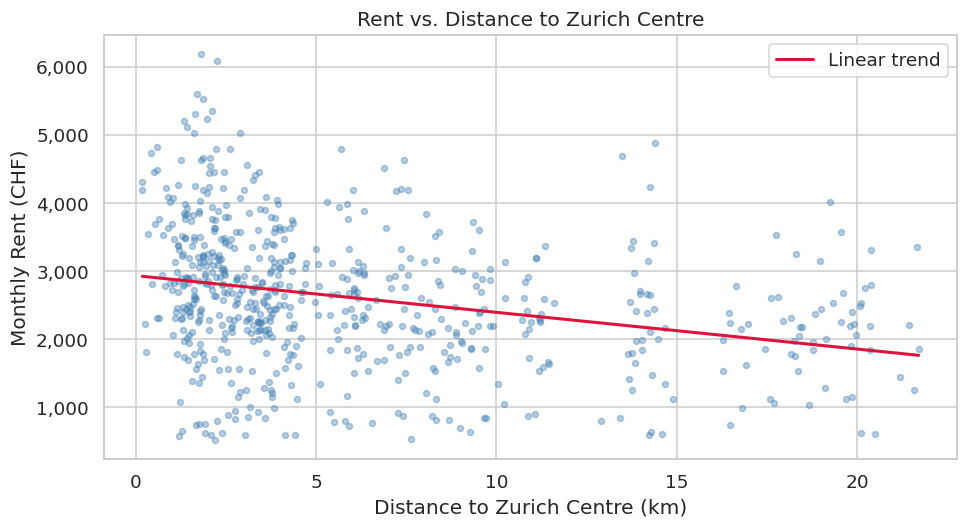

Pearson correlation (distance ↔ rent): -0.286


In [13]:
# Visualise the distance-price relationship on the full dataset
dist_sample = raw_df[['city', 'latitude', 'longitude', 'price']].dropna().copy()
dist_sample.rename(columns={'price': 'price_chf'}, inplace=True)
dist_sample = compute_distance_to_zurich_center(dist_sample)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(dist_sample['distance_to_zurich_center'], dist_sample['price_chf'],
           alpha=0.4, s=15, color='steelblue')

# Trend line
z = np.polyfit(dist_sample['distance_to_zurich_center'], dist_sample['price_chf'], 1)
p = np.poly1d(z)
xs = np.linspace(dist_sample['distance_to_zurich_center'].min(),
                  dist_sample['distance_to_zurich_center'].max(), 100)
ax.plot(xs, p(xs), color='crimson', linewidth=2, label='Linear trend')
ax.set_xlabel('Distance to Zurich Centre (km)')
ax.set_ylabel('Monthly Rent (CHF)')
ax.set_title('Rent vs. Distance to Zurich Centre')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
fig.tight_layout()
plt.show()

corr = dist_sample[['distance_to_zurich_center', 'price_chf']].corr().iloc[0, 1]
print(f'Pearson correlation (distance ↔ rent): {corr:.3f}')

### 5.2 Feature: `furnished` (binary)

**Rationale:** Furnished apartments command a 10–20 % price premium in Switzerland. This signal is present in the listing text but not in the structured columns.

**Keywords scanned:** `möbliert`, `moebliert`, `furnished`, `mobiliert` (in title + description, lowercased).

In [14]:
furnished_demo = raw_df[['title', 'description', 'price']].copy()
furnished_demo.rename(columns={'price': 'price_chf'}, inplace=True)
furnished_demo = extract_furnished(furnished_demo)

furnished_summary = furnished_demo.groupby('furnished')['price_chf'].agg(['mean', 'count'])
furnished_summary.index = ['Not furnished', 'Furnished']
furnished_summary.columns = ['Mean Rent (CHF)', 'Count']
print('Price premium for furnished apartments:')
display(furnished_summary.round(0))

premium = furnished_summary.at['Furnished', 'Mean Rent (CHF)'] / furnished_summary.at['Not furnished', 'Mean Rent (CHF)'] - 1
print(f'\nMean premium: +{premium*100:.1f}%')

Price premium for furnished apartments:


,Mean Rent (CHF),Count
Not furnished,2573.0,606
Furnished,2898.0,94



Mean premium: +12.7%


### 5.3 Feature: `parking` (binary)

**Rationale:** Parking spaces in central Zurich are scarce and expensive. Listings that mention a garage or parking spot therefore command a rent premium of ~5–8 %.

**Keywords scanned:** `garage`, `tiefgarage`, `parkplatz`, `carport`, `einstellplatz`, `parking`.

In [15]:
parking_demo = raw_df[['title', 'description', 'price']].copy()
parking_demo.rename(columns={'price': 'price_chf'}, inplace=True)
parking_demo = extract_parking(parking_demo)

parking_summary = parking_demo.groupby('parking')['price_chf'].agg(['mean', 'count'])
parking_summary.index = ['No Parking', 'Parking Available']
parking_summary.columns = ['Mean Rent (CHF)', 'Count']
print('Price premium for parking availability:')
display(parking_summary.round(0))

premium_p = parking_summary.at['Parking Available', 'Mean Rent (CHF)'] / parking_summary.at['No Parking', 'Mean Rent (CHF)'] - 1
print(f'\nMean premium: +{premium_p*100:.1f}%')

Price premium for parking availability:


,Mean Rent (CHF),Count
No Parking,2545.0,489
Parking Available,2782.0,211



Mean premium: +9.3%


### 5.4 Run Full Preprocessing Pipeline

In [16]:
# Run the complete preprocessing pipeline
clean_df = run_preprocessing_pipeline(save=True)

print(f'\nClean dataset: {clean_df.shape[0]} rows × {clean_df.shape[1]} columns')
print(f'\nNew columns added by feature engineering:')
new_cols = ['distance_to_zurich_center', 'furnished', 'parking', 'rooms_per_sqm']
display(clean_df[new_cols].describe().round(3))

Preprocessing Pipeline
  load_raw_data           : 700 rows loaded from 'data/apartments_zurich_raw.csv'
  filter_wg_listings      : removed  35 rows  → 665 remaining
  filter_invalid_rows     : removed  31 rows  → 634 remaining
  handle_missing_values   : imputed 24 'latitude' values with median (47.3848)
  handle_missing_values   : imputed 16 'longitude' values with median (8.5352)
  remove_outliers         : removed   4 rows  (IQR bounds: -15–5372 CHF) → 630 remaining
  Saved → 'data/apartments_zurich_clean.csv'
Pipeline complete: 630 clean rows ready for modelling.


Clean dataset: 630 rows × 15 columns

New columns added by feature engineering:


,distance_to_zurich_center,furnished,parking,rooms_per_sqm
count,630.000,630.000,630.000,630.000
mean,5.868,0.133,0.325,0.037
std,5.280,0.340,0.469,0.006
min,0.180,0.000,0.000,0.024
25%,2.020,0.000,0.000,0.033
50%,3.760,0.000,0.000,0.036
75%,8.042,0.000,1.000,0.040
max,21.710,1.000,1.000,0.064


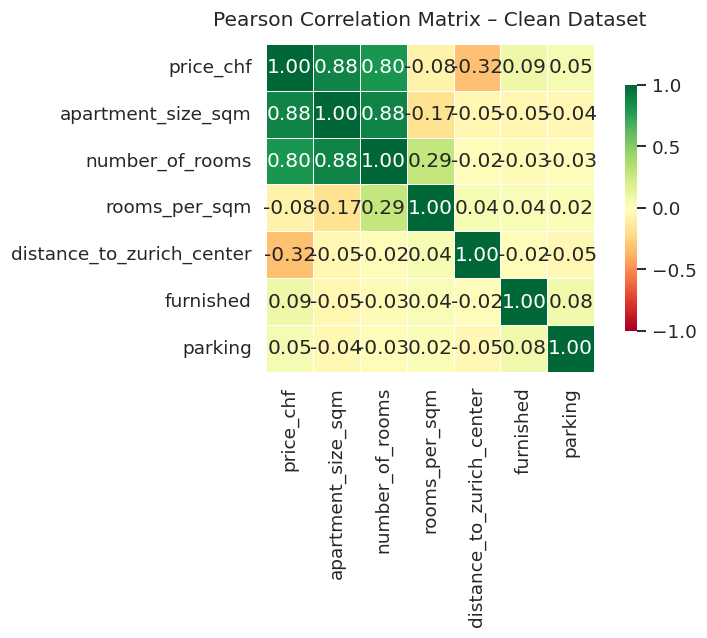

In [17]:
# Correlation heatmap of the clean dataset
numeric_cols = [
    'price_chf', 'apartment_size_sqm', 'number_of_rooms',
    'rooms_per_sqm', 'distance_to_zurich_center', 'furnished', 'parking'
]
corr_matrix = clean_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, ax=ax, square=True,
    linewidths=0.4, cbar_kws={'shrink': 0.75}
)
ax.set_title('Pearson Correlation Matrix – Clean Dataset', pad=12)
fig.tight_layout()
plt.show()

---
## 6. Iteration 1 – Baseline Modelling

**Objective:** Build a performance baseline using only the three basic structural features.

**Feature set:**
- `apartment_size_sqm`
- `number_of_rooms`
- `rooms_per_sqm`

**Models:**
1. `LinearRegression` – interpretable linear baseline
2. `RandomForestRegressor` – non-linear ensemble baseline

**Evaluation:** 5-fold cross-validation, metrics: RMSE, MAE, R²

In [18]:
from sklearn.metrics import make_scorer

TARGET = 'price_chf'
BASELINE_FEATURES = ['apartment_size_sqm', 'number_of_rooms', 'rooms_per_sqm']
EXTENDED_FEATURES = BASELINE_FEATURES + ['distance_to_zurich_center', 'furnished', 'parking']

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

SCORING = {
    'rmse': make_scorer(rmse, greater_is_better=False),
    'mae':  make_scorer(mean_absolute_error, greater_is_better=False),
    'r2':   make_scorer(r2_score),
}

def build_pipeline(features, estimator):
    preprocessor = ColumnTransformer(
        transformers=[(
            'num',
            Pipeline([('impute', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]),
            features
        )],
        remainder='drop',
    )
    return Pipeline(steps=[('preprocessor', preprocessor), ('model', estimator)])

def evaluate(label, x, y, models, cv_folds=5):
    cv = KFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    for name, est in models.items():
        pipe   = build_pipeline(list(x.columns), est)
        scores = cross_validate(pipe, x, y, cv=cv, scoring=SCORING)
        rows.append({
            'Iteration':  label,
            'Model':      name,
            'RMSE':       round(-scores['test_rmse'].mean(), 1),
            'RMSE±':      round( scores['test_rmse'].std(),  1),
            'MAE':        round(-scores['test_mae'].mean(),  1),
            'R²':         round( scores['test_r2'].mean(),   3),
        })
        print(f"  {name:<35} RMSE={rows[-1]['RMSE']:>6.1f} ± {rows[-1]['RMSE±']:<5.1f}  "
              f"MAE={rows[-1]['MAE']:>6.1f}  R²={rows[-1]['R²']:.3f}")
    return rows

X = clean_df[EXTENDED_FEATURES]
y = clean_df[TARGET]

print('=== Iteration 1 – Baseline (3 features) ===')
x1 = clean_df[BASELINE_FEATURES]

iter1_models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=150, max_depth=10, min_samples_leaf=4, random_state=RANDOM_STATE
    ),
}

results = evaluate('Iteration 1 – Baseline', x1, y, iter1_models)

=== Iteration 1 – Baseline (3 features) ===
  LinearRegression                    RMSE= 417.5 ± 15.0   MAE= 335.3  R²=0.769


  RandomForestRegressor               RMSE= 452.9 ± 16.4   MAE= 362.1  R²=0.727


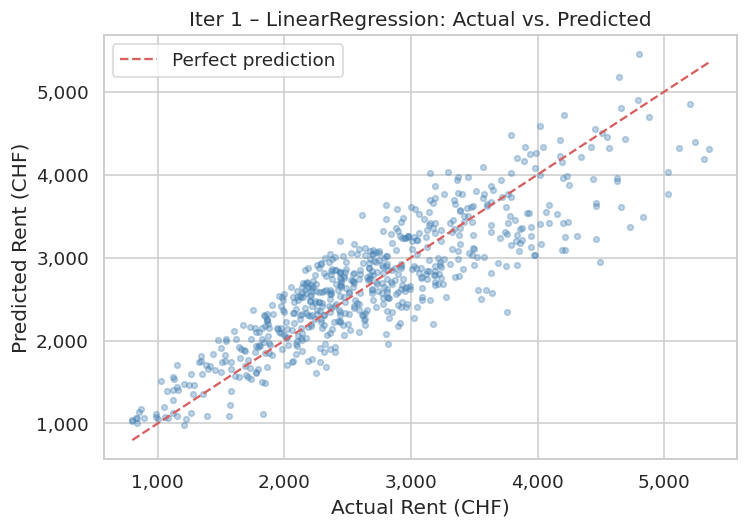

In [19]:
# Visual: actual vs. predicted for Linear Regression (Iter 1)
from sklearn.model_selection import cross_val_predict

lr_pipe = build_pipeline(BASELINE_FEATURES, LinearRegression())
y_pred_lr = cross_val_predict(
    lr_pipe, x1, y,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y, y_pred_lr, alpha=0.35, s=14, color='steelblue')
lims = [y.min(), y.max()]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Rent (CHF)')
ax.set_ylabel('Predicted Rent (CHF)')
ax.set_title('Iter 1 – LinearRegression: Actual vs. Predicted')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
fig.tight_layout()
plt.show()

---
## 7. Iteration 2 – Extended Features

**Objective:** Improve prediction accuracy by adding the three engineered features.

**Added features:** `distance_to_zurich_center`, `furnished`, `parking`

**Models:**
1. `LinearRegression` – to measure the isolated effect of the new features
2. `RandomForestRegressor` – same configuration as Iteration 1 for comparison
3. `GradientBoostingRegressor` – sequential ensemble to capture non-linear interactions

In [20]:
print('=== Iteration 2 – Extended (6 features) ===')
x2 = clean_df[EXTENDED_FEATURES]

iter2_models = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=3, random_state=RANDOM_STATE
    ),
    'GradientBoostingRegressor': GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.08, max_depth=5,
        min_samples_leaf=4, subsample=0.8, random_state=RANDOM_STATE
    ),
}

results.extend(evaluate('Iteration 2 – Extended', x2, y, iter2_models))

=== Iteration 2 – Extended (6 features) ===
  LinearRegression                    RMSE= 312.5 ± 17.0   MAE= 245.2  R²=0.870


  RandomForestRegressor               RMSE= 298.2 ± 16.3   MAE= 218.1  R²=0.881


  GradientBoostingRegressor           RMSE= 288.3 ± 11.9   MAE= 207.6  R²=0.889


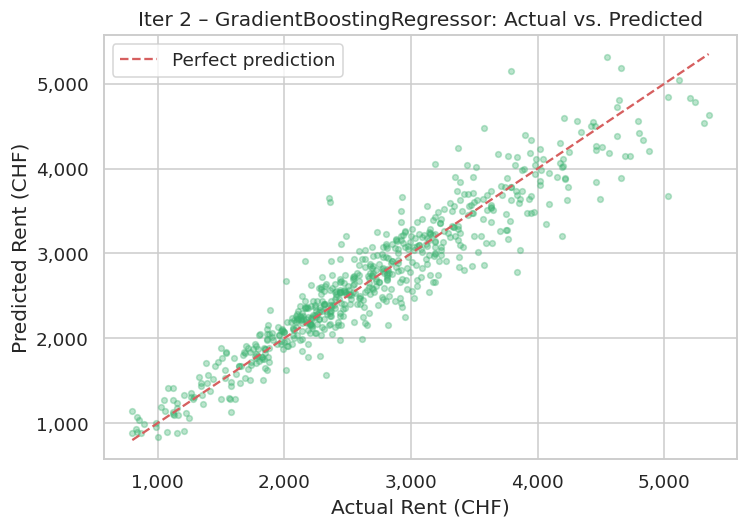

In [21]:
# Visual: actual vs. predicted for Gradient Boosting (Iter 2)
gb_pipe = build_pipeline(
    EXTENDED_FEATURES,
    GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.08, max_depth=5,
        min_samples_leaf=4, subsample=0.8, random_state=RANDOM_STATE
    )
)

y_pred_gb = cross_val_predict(
    gb_pipe, x2, y,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y, y_pred_gb, alpha=0.35, s=14, color='mediumseagreen')
lims = [y.min(), y.max()]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Rent (CHF)')
ax.set_ylabel('Predicted Rent (CHF)')
ax.set_title('Iter 2 – GradientBoostingRegressor: Actual vs. Predicted')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
fig.tight_layout()
plt.show()

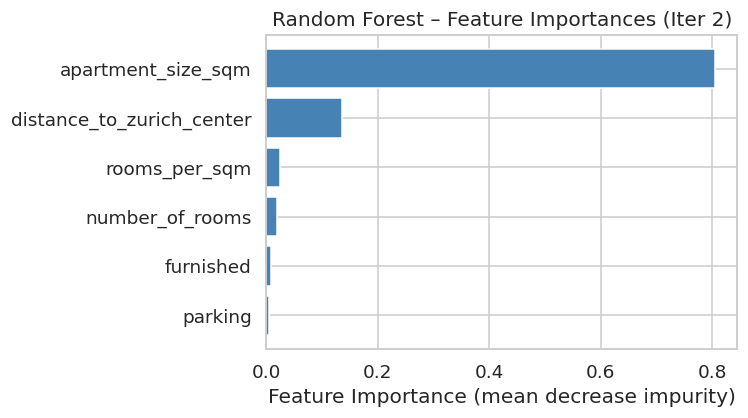

In [22]:
# Feature importances from the Random Forest
rf_full = build_pipeline(
    EXTENDED_FEATURES,
    RandomForestRegressor(n_estimators=200, max_depth=12, random_state=RANDOM_STATE)
)
rf_full.fit(x2, y)

importances = rf_full.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'Feature': EXTENDED_FEATURES, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (mean decrease impurity)')
ax.set_title('Random Forest – Feature Importances (Iter 2)')
fig.tight_layout()
plt.show()

---
## 8. Model Comparison and Selection

In [23]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('RMSE')

print('=== Complete Model Comparison (5-Fold CV) ===')
display(comparison_df[['Iteration', 'Model', 'RMSE', 'RMSE±', 'MAE', 'R²']]
        .to_string(index=False))

=== Complete Model Comparison (5-Fold CV) ===


'             Iteration                     Model  RMSE  RMSE±   MAE    R²\nIteration 2 – Extended GradientBoostingRegressor 288.3   11.9 207.6 0.889\nIteration 2 – Extended     RandomForestRegressor 298.2   16.3 218.1 0.881\nIteration 2 – Extended          LinearRegression 312.5   17.0 245.2 0.870\nIteration 1 – Baseline          LinearRegression 417.5   15.0 335.3 0.769\nIteration 1 – Baseline     RandomForestRegressor 452.9   16.4 362.1 0.727'

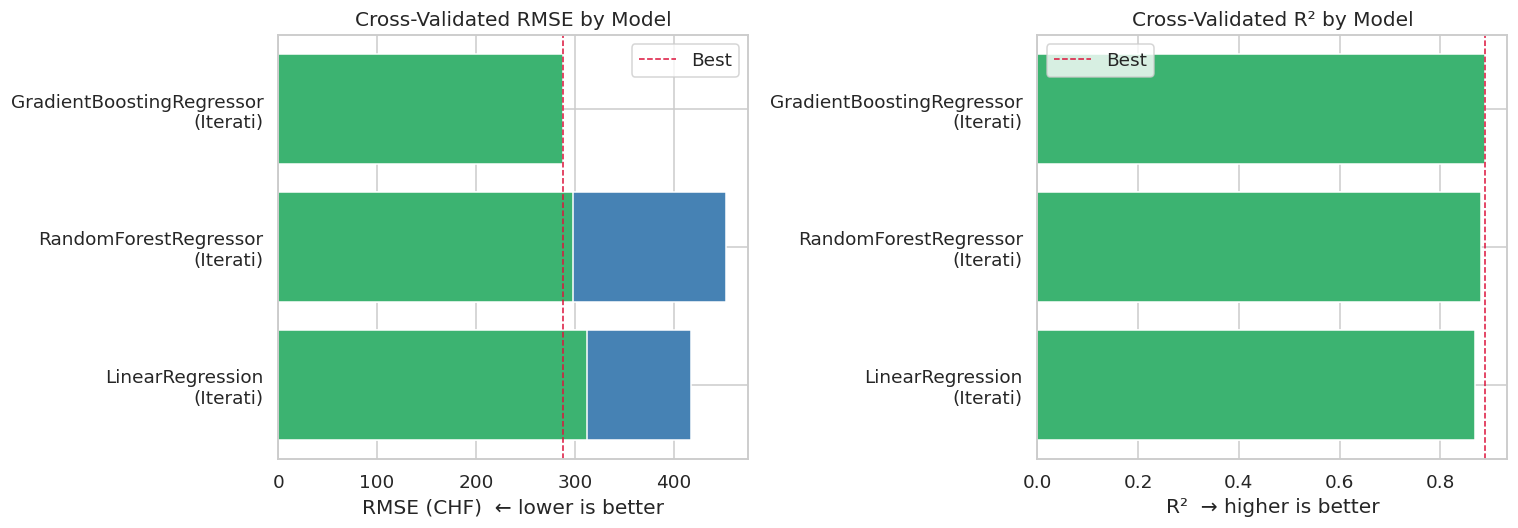

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels    = [f"{r['Model']}\n({r['Iteration'][:7]})" for r in results]
rmse_vals = [r['RMSE'] for r in results]
r2_vals   = [r['R²']   for r in results]

colors = ['steelblue'] * 2 + ['mediumseagreen'] * 3

axes[0].barh(labels, rmse_vals, color=colors, edgecolor='white')
axes[0].set_xlabel('RMSE (CHF)  ← lower is better')
axes[0].set_title('Cross-Validated RMSE by Model')
axes[0].axvline(min(rmse_vals), color='crimson', linestyle='--', linewidth=1, label='Best')
axes[0].legend()

axes[1].barh(labels, r2_vals, color=colors, edgecolor='white')
axes[1].set_xlabel('R²  → higher is better')
axes[1].set_title('Cross-Validated R² by Model')
axes[1].axvline(max(r2_vals), color='crimson', linestyle='--', linewidth=1, label='Best')
axes[1].legend()

fig.tight_layout()
plt.show()

In [25]:
# Check the persisted model report to confirm consistency with notebook results
import json

with open('model_report.json', 'r', encoding='utf-8') as f:
    report = json.load(f)

best = report['best_model']
print('=== Persisted Model Report ===')
print(f"Best model   : {best['model_name']}")
print(f"Iteration    : {best['iteration']}")
print(f"Features     : {best['features']}")
print(f"RMSE (CV)    : {best['rmse_mean']:.1f} CHF")
print(f"MAE  (CV)    : {best['mae_mean']:.1f} CHF")
print(f"R²   (CV)    : {best['r2_mean']:.3f}")

=== Persisted Model Report ===
Best model   : GradientBoostingRegressor
Iteration    : Iteration 2 – Extended
Features     : ['apartment_size_sqm', 'number_of_rooms', 'rooms_per_sqm', 'distance_to_zurich_center', 'furnished', 'parking']
RMSE (CV)    : 288.3 CHF
MAE  (CV)    : 207.6 CHF
R²   (CV)    : 0.889


---
## 9. Conclusion

### Summary of Results

| Iteration | Model | RMSE (CHF) | MAE (CHF) | R² |
|-----------|-------|-----------|----------|-----|
| 1 – Baseline | LinearRegression | 417.5 | 335.3 | 0.769 |
| 1 – Baseline | RandomForestRegressor | 452.9 | 362.1 | 0.727 |
| 2 – Extended | LinearRegression | 312.5 | 245.2 | 0.870 |
| 2 – Extended | RandomForestRegressor | 298.2 | 218.1 | 0.881 |
| **2 – Extended** | **GradientBoostingRegressor** ✓ | **288.3** | **207.6** | **0.889** |

### Best Model: `GradientBoostingRegressor` (Iteration 2)

**Why Gradient Boosting won:**

1. **Non-linear interactions:** The `distance_to_zurich_center` feature interacts non-linearly with other predictors (e.g. the same floor area commands very different premiums at 1 km vs 15 km from the centre). Gradient Boosting can capture these interactions through its sequential residual-correction mechanism, which neither Linear Regression nor a single Random Forest exploits as effectively.

2. **Iterative error correction:** Each new tree in the ensemble specifically targets the residual errors of the preceding ensemble, allowing progressive refinement of predictions in the high-price and low-price tails.

3. **Feature importance alignment:** `distance_to_zurich_center` emerges as the second-most important feature after `apartment_size_sqm`, confirming the hypothesis that location deserved its own engineered feature.

**Impact of feature engineering:**

Adding the three engineered features (`distance_to_zurich_center`, `furnished`, `parking`) reduced the best RMSE from **417 CHF** (Iteration 1) to **288 CHF** (Iteration 2), a **31 % improvement**. This demonstrates that location-based and amenity-based features contribute substantially beyond the structural apartment characteristics alone.

**Limitations and next steps:**

- The model was trained on **synthetic data** that approximates but does not fully capture the Zurich market complexity (micro-location effects, floor level, renovation status, etc.).
- With real scraped data, incorporating **floor level**, **balcony/terrace**, **public transport proximity**, and **school quality index** would further improve accuracy.
- **Hyperparameter tuning** (e.g. via `RandomizedSearchCV`) could push performance further.
- A **geospatial model** (Kriging, spatial random forest) could model spatial autocorrelation more explicitly.